## Training Script

Cell below runs as an isolated python script

In [2]:
!python experiment.py

🏃 View run trial_2 at: http://localhost:5000/#/experiments/34/runs/308b18ba746445c6a46bc80581603223
🧪 View experiment at: http://localhost:5000/#/experiments/34
🏃 View run trial_1 at: http://localhost:5000/#/experiments/34/runs/6346a2d3fe9d43239f66d4b7f73ea303
🧪 View experiment at: http://localhost:5000/#/experiments/34
🏃 View run trial_4 at: http://localhost:5000/#/experiments/34/runs/3db2828be5e94b53825db1df39668d66
🧪 View experiment at: http://localhost:5000/#/experiments/34
🏃 View run trial_0 at: http://localhost:5000/#/experiments/34/runs/b7607ba410a14604b288797bc11394f5
🧪 View experiment at: http://localhost:5000/#/experiments/34
🏃 View run trial_15 at: http://localhost:5000/#/experiments/34/runs/f5ea79135d7341fa8140ef86b440699d
🧪 View experiment at: http://localhost:5000/#/experiments/34
🏃 View run trial_8 at: http://localhost:5000/#/experiments/34/runs/0d3646b813714a45956d8d806367e850
🧪 View experiment at: http://localhost:5000/#/experiments/34
🏃 View run trial_7 at: http://loc

c:\Users\jjaramil\OneDrive - InterSystems Corporation\Documents\CICD\Continuous-Training-in-IRIS\dur\sandbox\experiment.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df =  pd.read_sql(f"SELECT * FROM MLpipeline.PointSamples", cnxn)
2026/05/18 08:09:48 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/05/18 08:09:48 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
[I 2026-05-18 08:09:48,592] A new study created in RDB with name: optuna_2026-05-18 08:09
[W 2026-05-18 08:09:50,275] Trial 2 failed with parameters: {'learning_rate': 0.0045959686566912576, 'max_depth': 24, 'n_estimators': 257, 'num_leaves': 63, 'lambda_l2': 7.737742277705769e-07, 'max_bin': 63} because of the following error: ValueError('\nAll the 10 fi

## Loading Model

In [1]:
import os
import mlflow

In [6]:
runid = "7d1eccc9f5b24367a5e02c47f24d8af9"
model = mlflow.lightgbm.load_model(f"runs:/{runid}/best_model")


In [7]:
mlflow.lightgbm.save_model(model, f"local_test_model/{runid}")

2026/05/18 08:38:11 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [8]:
model = mlflow.lightgbm.load_model(f"local_test_model/{runid}")

## Testing

In [9]:
import datetime as dt
from drawdata import ScatterWidget
import pandas as pd
import matplotlib.pyplot as plt

widget = ScatterWidget(height=400, width=400)
widget

In [16]:
df = widget.data_as_pandas[["x", "y", "label"]]
df["datetime"] = dt.datetime.now()
df.head()

,x,y,label,datetime
0,12.099112,215.091939,c,2026-05-18 08:44:56.001423
1,6.979138,217.665136,c,2026-05-18 08:44:56.001423
2,0.653644,209.351375,c,2026-05-18 08:44:56.001423
3,17.097733,219.555735,c,2026-05-18 08:44:56.001423
4,13.928933,224.412405,c,2026-05-18 08:44:56.001423


C:\Users\jjaramil\AppData\Local\Temp\ipykernel_8404\1070969237.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["year"] = df["datetime"].dt.year


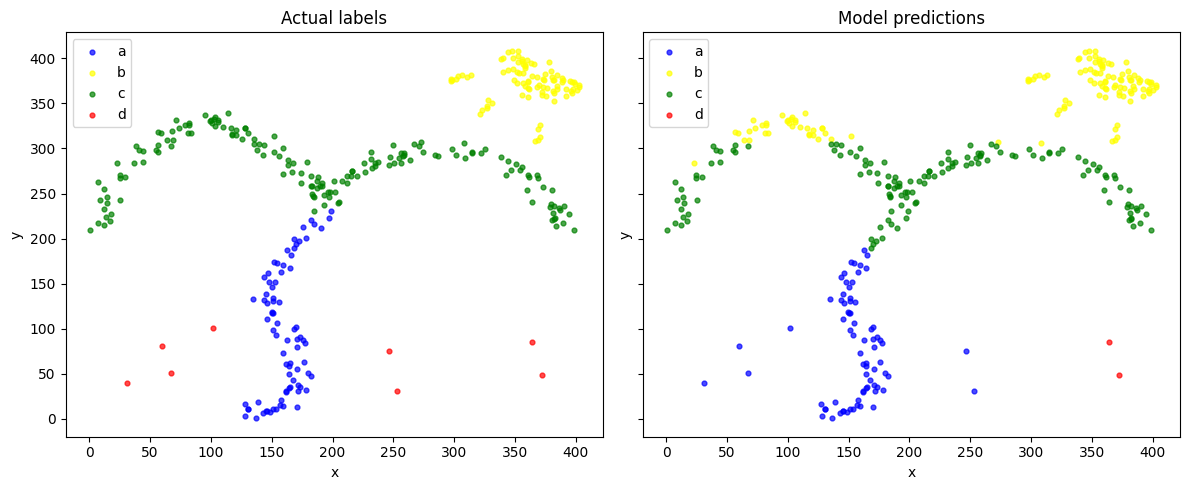

In [25]:
import matplotlib.pyplot as plt

color_map = {'a': 'blue', 'b': 'yellow', 'c': 'green', 'd': 'red'}

X = df[["x", "y"]]
X["year"] = df["datetime"].dt.year
X["month"] = df["datetime"].dt.month
X["day"] = df["datetime"].dt.day
X["hour"] = df["datetime"].dt.hour
X["minute"] = df["datetime"].dt.minute
X["second"] = df["datetime"].dt.second
y = df["label"]

pred = model.predict(X)
plot_df = df.copy()
plot_df["pred"] = pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for label, color in color_map.items():
    actual = plot_df[plot_df["label"] == label]
    axes[0].scatter(actual["x"], actual["y"], s=12, c=color, label=label, alpha=0.7)

    predicted = plot_df[plot_df["pred"] == label]
    axes[1].scatter(predicted["x"], predicted["y"], s=12, c=color, label=label, alpha=0.7)

axes[0].set_title("Actual labels")
axes[1].set_title("Model predictions")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

plt.tight_layout()
plt.show()

In [26]:
X

,x,y,year,month,day,hour,minute,second
0,12.099112,215.091939,2026,5,18,8,44,56
1,6.979138,217.665136,2026,5,18,8,44,56
2,0.653644,209.351375,2026,5,18,8,44,56
3,17.097733,219.555735,2026,5,18,8,44,56
4,13.928933,224.412405,2026,5,18,8,44,56
...,...,...,...,...,...,...,...,...
339,364.267173,84.802361,2026,5,18,8,44,56
340,372.517151,48.488175,2026,5,18,8,44,56
341,246.586205,75.465936,2026,5,18,8,44,56
342,67.205200,50.575915,2026,5,18,8,44,56


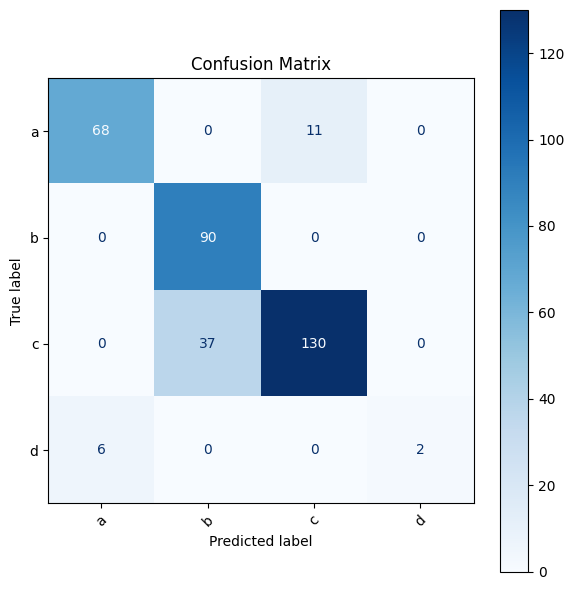

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = sorted(set(plot_df["label"]) | set(plot_df["pred"]))
cm = confusion_matrix(plot_df["label"], plot_df["pred"], labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Explainability

In [28]:
X

,x,y,year,month,day,hour,minute,second
0,12.099112,215.091939,2026,5,18,8,44,56
1,6.979138,217.665136,2026,5,18,8,44,56
2,0.653644,209.351375,2026,5,18,8,44,56
3,17.097733,219.555735,2026,5,18,8,44,56
4,13.928933,224.412405,2026,5,18,8,44,56
...,...,...,...,...,...,...,...,...
339,364.267173,84.802361,2026,5,18,8,44,56
340,372.517151,48.488175,2026,5,18,8,44,56
341,246.586205,75.465936,2026,5,18,8,44,56
342,67.205200,50.575915,2026,5,18,8,44,56


In [29]:
import os
import dotenv
import pyodbc
import shap

dotenv.load_dotenv()

class_index = list(model.classes_).index("a") # SELECT CLASS TO EXPLAIN
sample_ind = 304 # SELECT POINT TO EXPLAIN


def predict_fn(data):
    data = pd.DataFrame(data, columns=["x", "y", "year", "month", "day", "hour", "minute", "second"])
    return model.predict_proba(data)[:, class_index]

X100 = shap.utils.sample(X, 100) # Subsample to use as background dataset
explainer = shap.Explainer(predict_fn, X100)
shap_values = explainer(X)

probabilities for chosen sample

In [30]:
proba = model.predict_proba(X.iloc[sample_ind : sample_ind + 1])[0]
{c: prob for c, prob in zip(model.classes_, proba)}

{'a': np.float64(0.05886118705399388),
 'b': np.float64(0.8720513002199562),
 'c': np.float64(0.06567731161916905),
 'd': np.float64(0.003410201106880933)}

In [31]:
import plotly.graph_objects as go

# Create scatter plot with plotly
fig = go.Figure()

for label, color_map_val in zip(color_map.keys(), ['blue', 'yellow', 'green', 'red']):
    predicted = plot_df[plot_df["pred"] == label]
    fig.add_trace(go.Scatter(
        x=predicted["x"],
        y=predicted["y"],
        mode='markers',
        name=label,
        marker=dict(size=6, color=color_map_val, opacity=0.7),
        customdata=predicted.index.to_numpy(),
        hovertemplate="sample id: %{customdata}<extra></extra>"
    ))

# Highlight sample_ind
selected = plot_df.iloc[sample_ind]
fig.add_trace(go.Scatter(
    x=[selected["x"]],
    y=[selected["y"]],
    mode='markers+text',
    name=f"sample_{sample_ind}",
    text=[f"sample {sample_ind}"],
    textposition='top center',
    marker=dict(size=14, color='black', symbol='x', line=dict(width=2, color='white')),
    customdata=[selected.name],
    hovertemplate="sample id: %{customdata}<extra></extra>"
))

fig.update_layout(
    title="Model Predictions",
    xaxis_title="x",
    yaxis_title="y",
    hovermode='closest',
    height=600,
    width=800
)

fig.show()

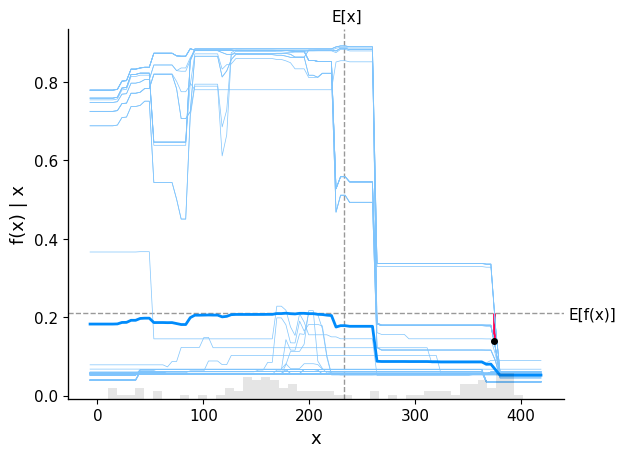

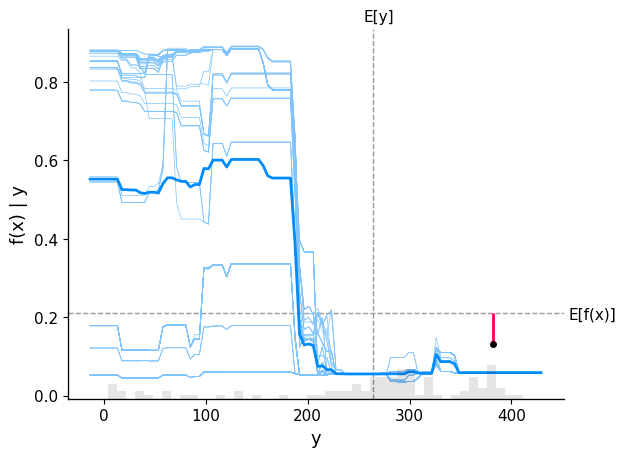

In [33]:
def predict_class(data):
    data = pd.DataFrame(data, columns=["x", "y", "year", "month", "day", "hour", "minute", "second"])
    return model.predict_proba(data)[:, class_index]


shap.partial_dependence_plot(
    "x",
    predict_class,
    X100,
    ice=True,
    model_expected_value=True,
    feature_expected_value=True,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

shap.partial_dependence_plot(
    "y",
    predict_class,
    X100,
    ice=True,
    model_expected_value=True,
    feature_expected_value=True,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

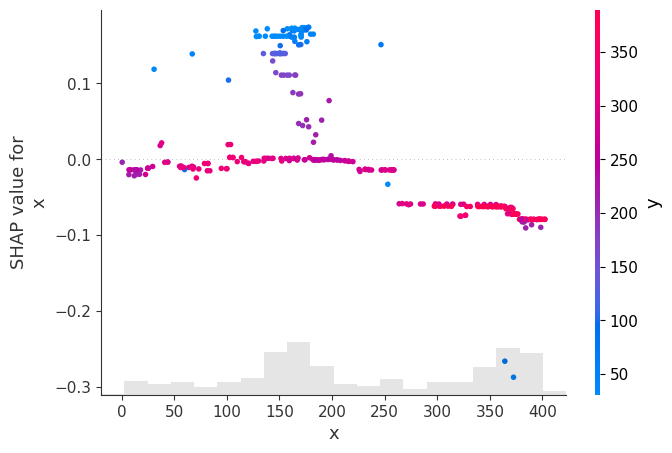

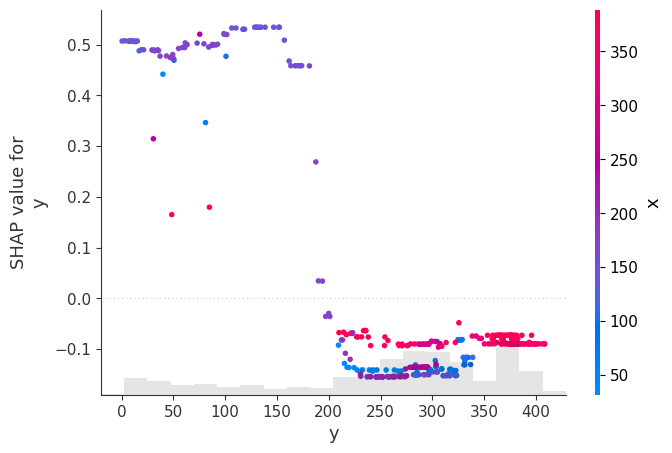

In [34]:
shap.plots.scatter(shap_values[:, "x"], color=shap_values)
shap.plots.scatter(shap_values[:, "y"], color=shap_values)

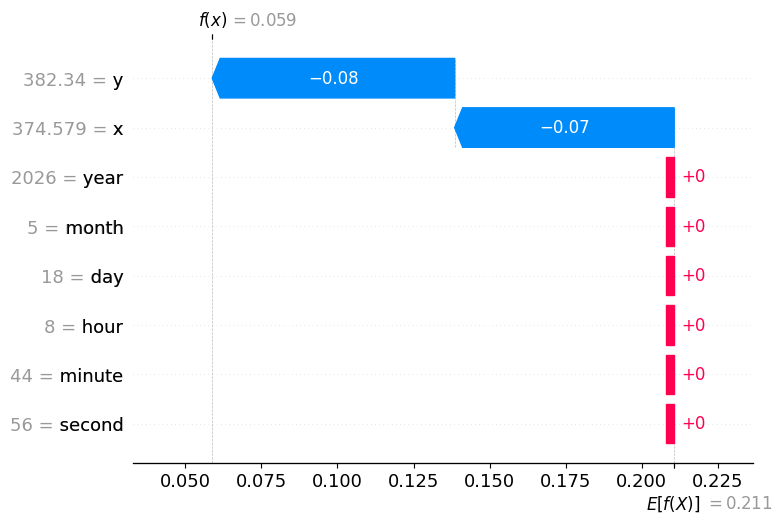

In [35]:
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

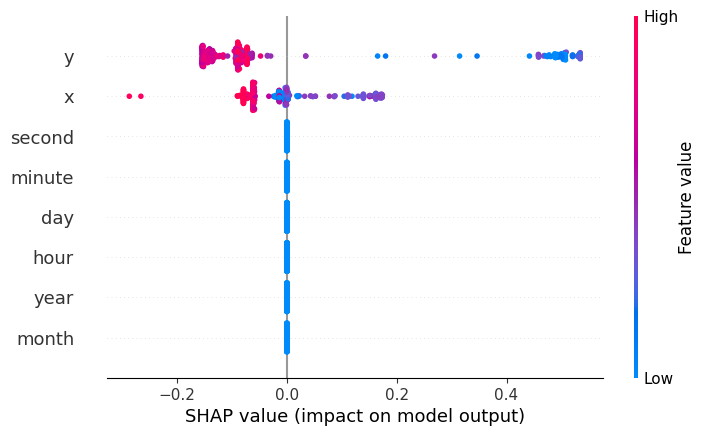

In [36]:
shap.plots.beeswarm(shap_values)